# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *
import torch
from torch.utils.data import DataLoader, random_split
import time
import numpy as np
import matplotlib.pyplot as plt

## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

## Modelo

- falar sobre o modelo escolhido: Unet Binaria e D dimensional

## Métricas

- mostrar como as metricas estao sendo calculadas

A regra de matching utilizada foi a guloso por IoU.

## Parte 0 - Teste Unitário

In [2]:
# Created the synthetic images 
synthetic_train = build_dataset("synthetic", num_samples=536, img_size=128)
synthetic_val = build_dataset("synthetic", num_samples=134, img_size=128)
# synthetic_test = build_dataset("synthetic", num_samples=65, img_size=128)

# Create data loaders
synthetic_train_loader = DataLoader(synthetic_train, batch_size=8, shuffle=True)
synthetic_val_loader = DataLoader(synthetic_val, batch_size=8, shuffle=False)
# synthetic_test_loader = DataLoader(synthetic_test, batch_size=8, shuffle=False)

# Train and evaluate the model
synthetic_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start = time.time()
train_model(synthetic_model, synthetic_train_loader, device, part=1, num_epochs=5)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")


Epoch 1/5 | Loss: 0.1618 | IoU: 0.8851 | Dice: 0.9390
Epoch 2/5 | Loss: 0.0318 | IoU: 0.9806 | Dice: 0.9902
Epoch 3/5 | Loss: 0.0149 | IoU: 0.9919 | Dice: 0.9959
Epoch 4/5 | Loss: 0.0088 | IoU: 0.9957 | Dice: 0.9978
Epoch 5/5 | Loss: 0.0059 | IoU: 0.9973 | Dice: 0.9987
Training time: 2.69 minutes


Média global mAP: 0.0897
Média global Erro Absoluto de Contagem: 9.6119


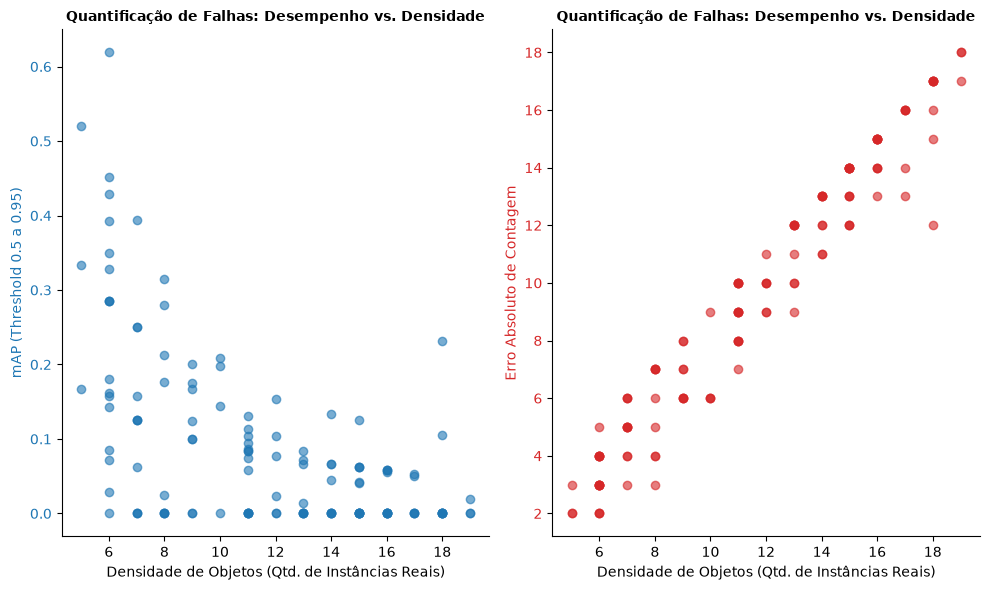

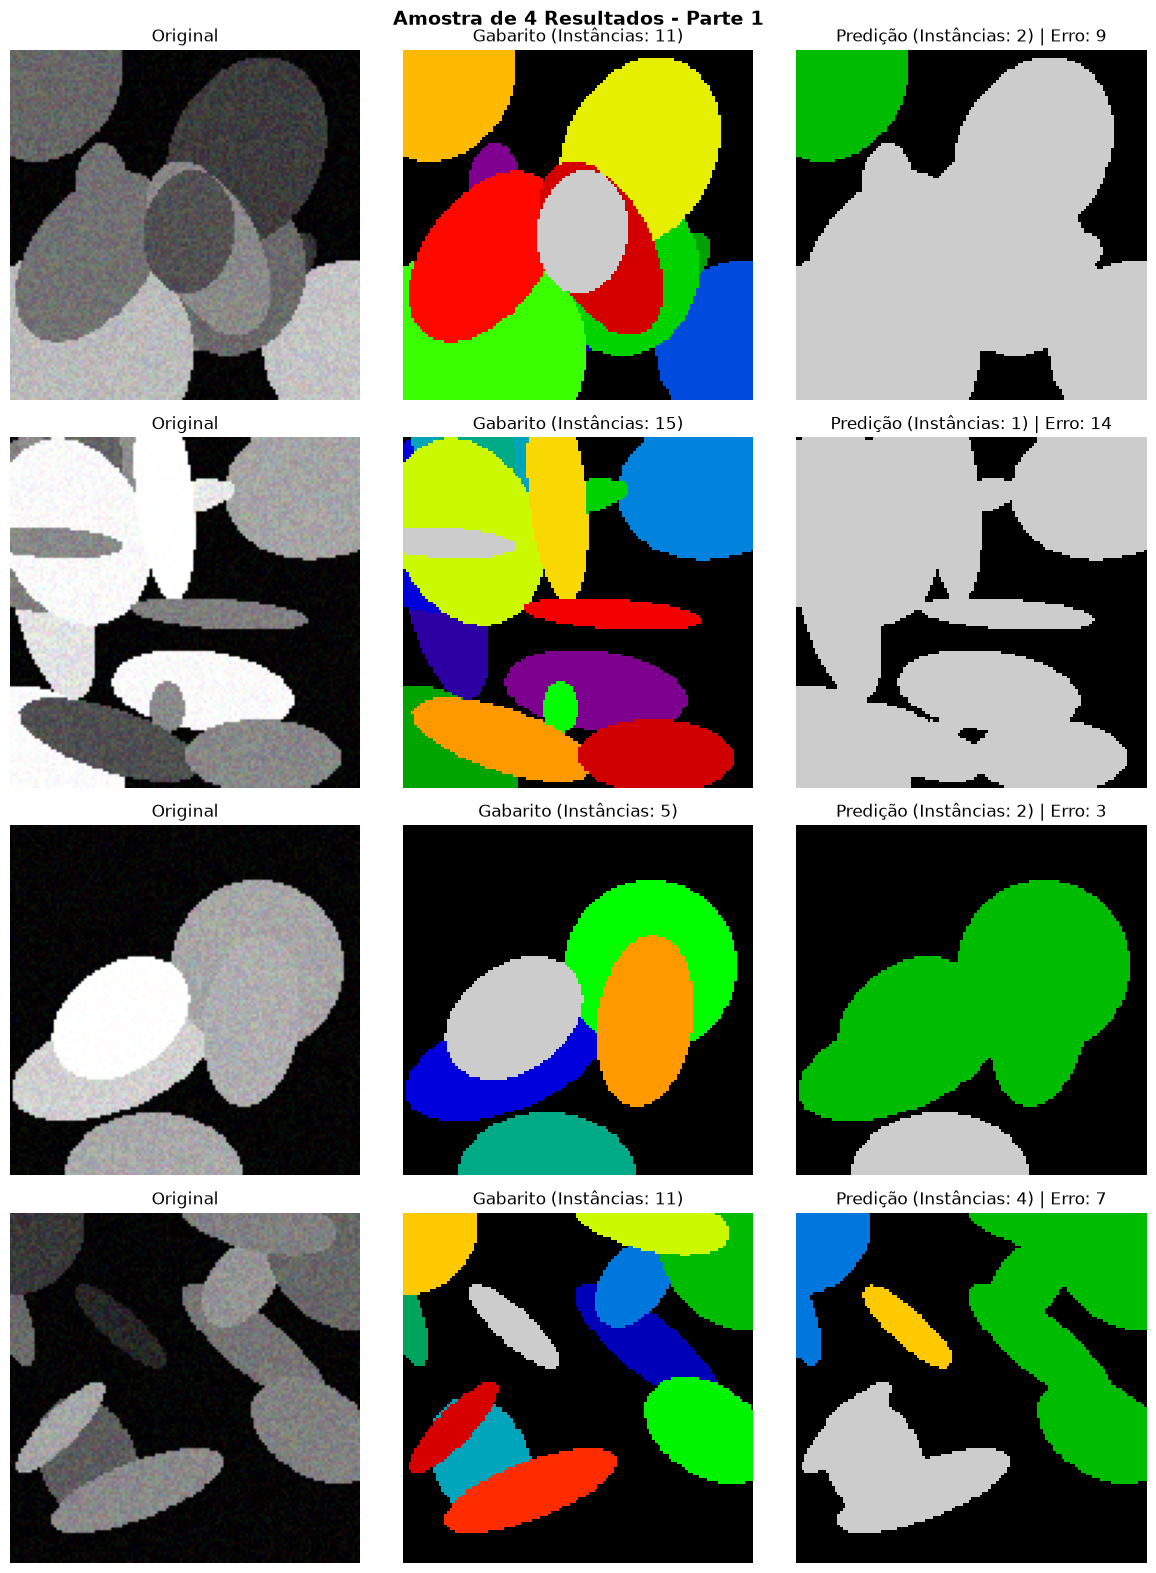

In [3]:
synthetic_mAP, synthetic_count_errors, synthetic_densities, synthetic_samples = evaluate(synthetic_model, synthetic_val_loader, device, part =1)
plot_metrics(synthetic_mAP, synthetic_count_errors, synthetic_densities)
plot_samples(synthetic_samples, part=1)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

## Parte 1

In [4]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=1, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Epoch 1/10 | Loss: 0.2745 | IoU: 0.2365 | Dice: 0.3825
Epoch 2/10 | Loss: 0.1382 | IoU: 0.6541 | Dice: 0.7909
Epoch 3/10 | Loss: 0.1193 | IoU: 0.6946 | Dice: 0.8198
Epoch 4/10 | Loss: 0.1015 | IoU: 0.7382 | Dice: 0.8494
Epoch 5/10 | Loss: 0.0956 | IoU: 0.7486 | Dice: 0.8562
Epoch 6/10 | Loss: 0.0873 | IoU: 0.7701 | Dice: 0.8701
Epoch 7/10 | Loss: 0.0875 | IoU: 0.7674 | Dice: 0.8684
Epoch 8/10 | Loss: 0.0837 | IoU: 0.7772 | Dice: 0.8747
Epoch 9/10 | Loss: 0.0795 | IoU: 0.7879 | Dice: 0.8813
Epoch 10/10 | Loss: 0.0786 | IoU: 0.7910 | Dice: 0.8833


Failed to reload module 'src.models' from file '/home/jaimewillian/Documentos/FGV/6P/DL/deep-learning-assignments/assignment-01/src/models.py'
Traceback (most recent call last):
  File "/home/jaimewillian/Documentos/FGV/6P/DL/deep-learning-assignments/.venv/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 326, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jaimewillian/Documentos/FGV/6P/DL/deep-learning-assignments/.venv/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
  File "/usr/lib/python3.14/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 869, in _exec
  File "<frozen importlib._bootstrap_external>", line 755, in exec_module
  File "<frozen importlib._bootstrap_external>", line 893, in get_code
  File "<frozen importlib.

Média global mAP: 0.3557
Média global Erro Absoluto de Contagem: 15.7612


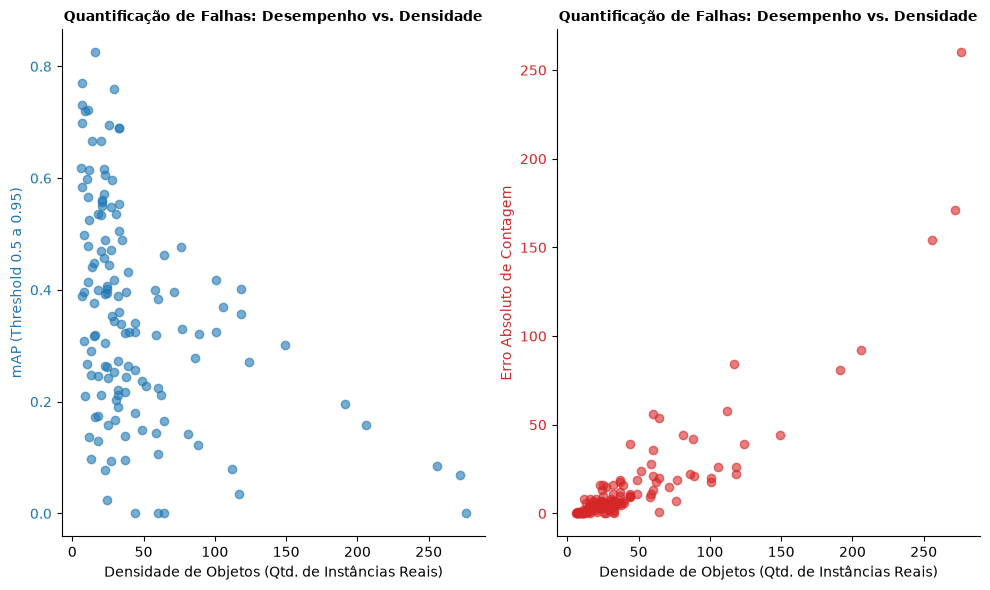

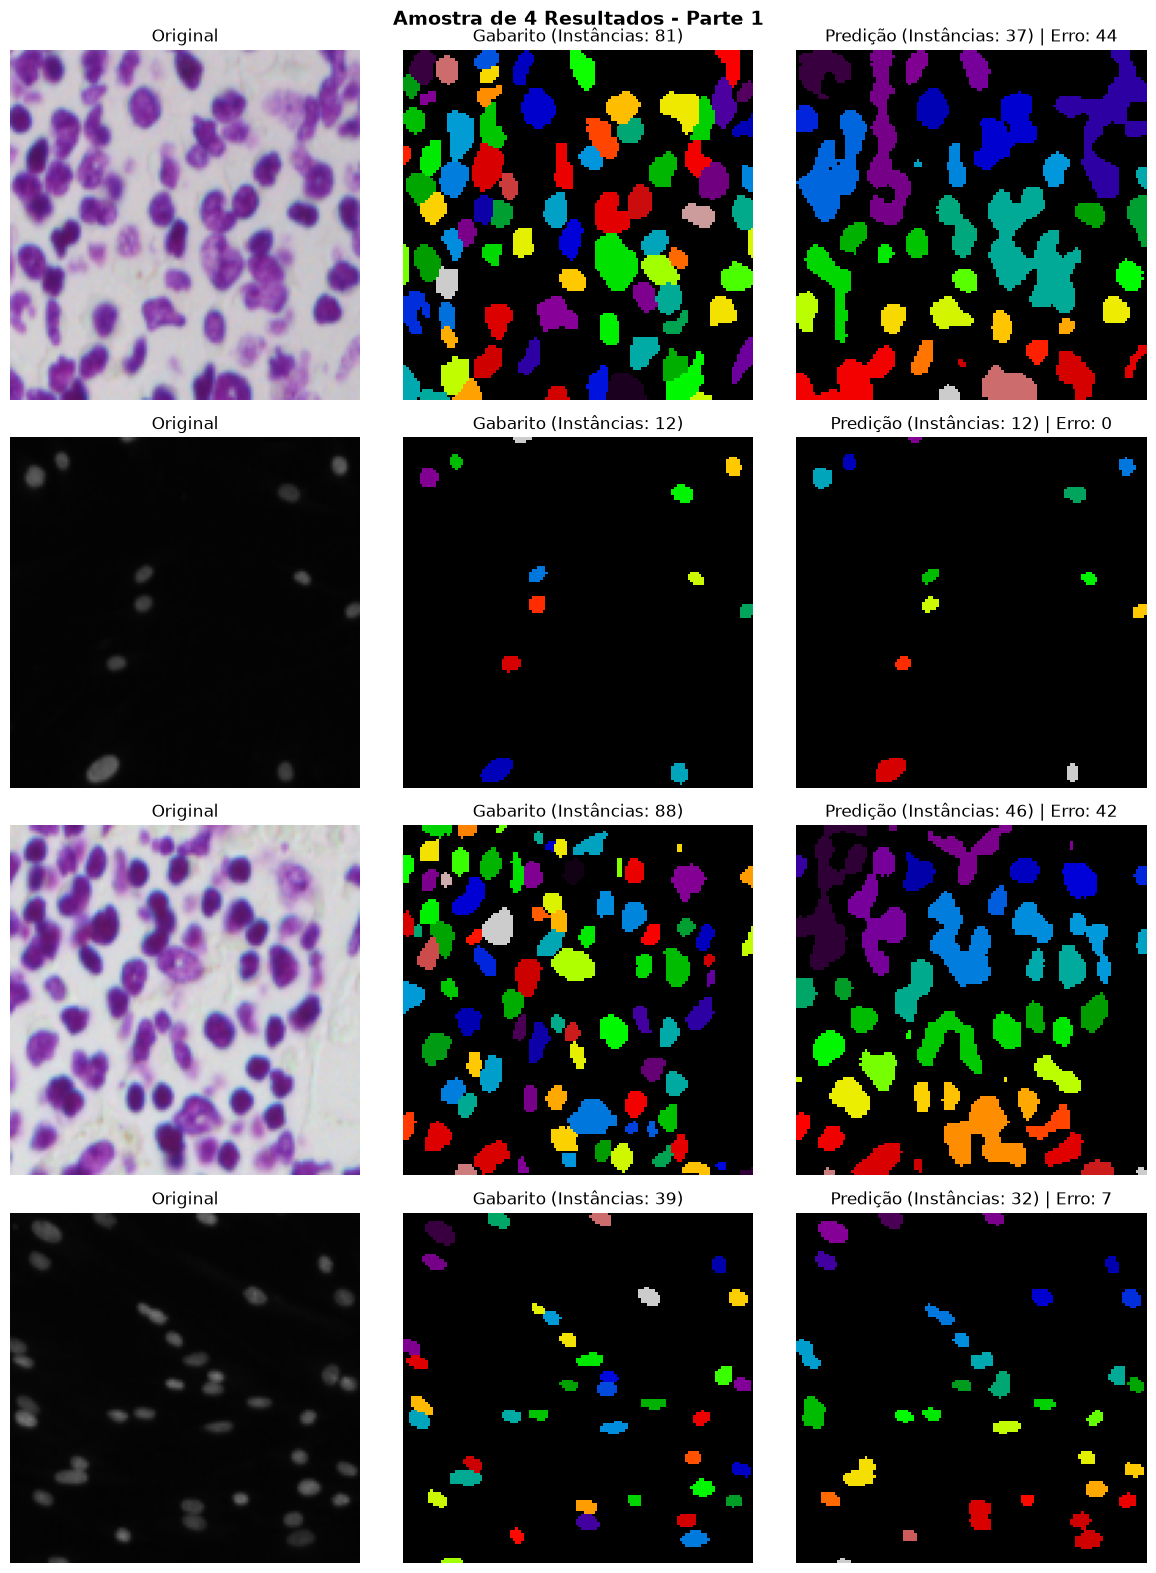

In [5]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate(real_model, real_val_loader, device, part =1)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=1)

Parte 2 - Trilha B

In [6]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetDDimensional(D=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=2, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Epoch 1/10 | Loss: 12.1520 | IoU: 0.0494 | Dice: 0.0941
Epoch 2/10 | Loss: 7.0061 | IoU: 0.0000 | Dice: 0.0000
Epoch 3/10 | Loss: 4.9018 | IoU: 0.0002 | Dice: 0.0003
Epoch 4/10 | Loss: 4.3680 | IoU: 0.0000 | Dice: 0.0000
Epoch 5/10 | Loss: 4.1963 | IoU: 0.0000 | Dice: 0.0000
Epoch 6/10 | Loss: 4.1032 | IoU: 0.0042 | Dice: 0.0083
Epoch 7/10 | Loss: 3.9447 | IoU: 0.1676 | Dice: 0.2870
Epoch 8/10 | Loss: 3.8806 | IoU: 0.5009 | Dice: 0.6674
Epoch 9/10 | Loss: 3.7708 | IoU: 0.5956 | Dice: 0.7465
Epoch 10/10 | Loss: 3.7293 | IoU: 0.6273 | Dice: 0.7710


Média global mAP: 0.0824
Média global Erro Absoluto de Contagem: 31.2687


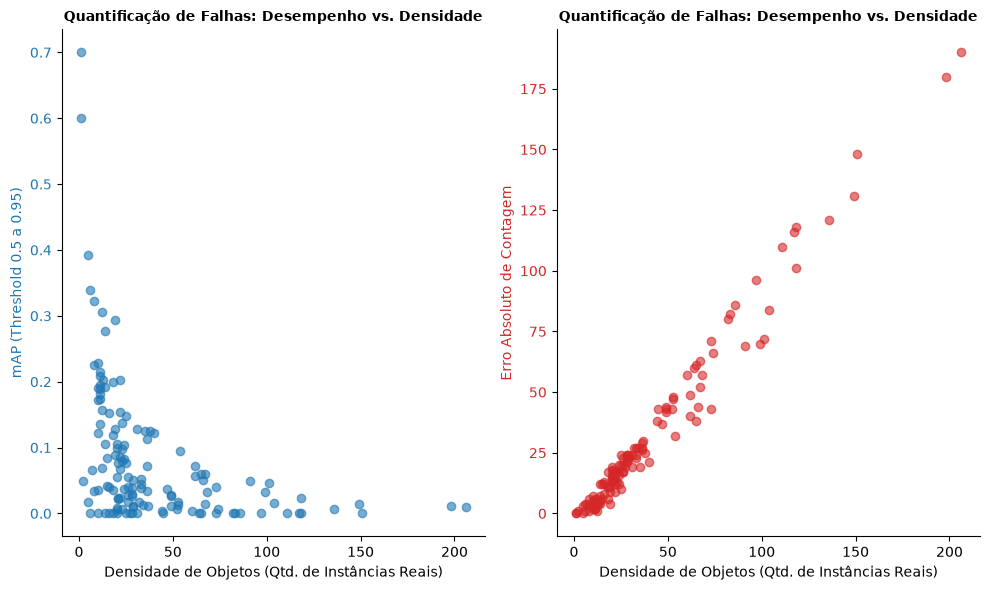

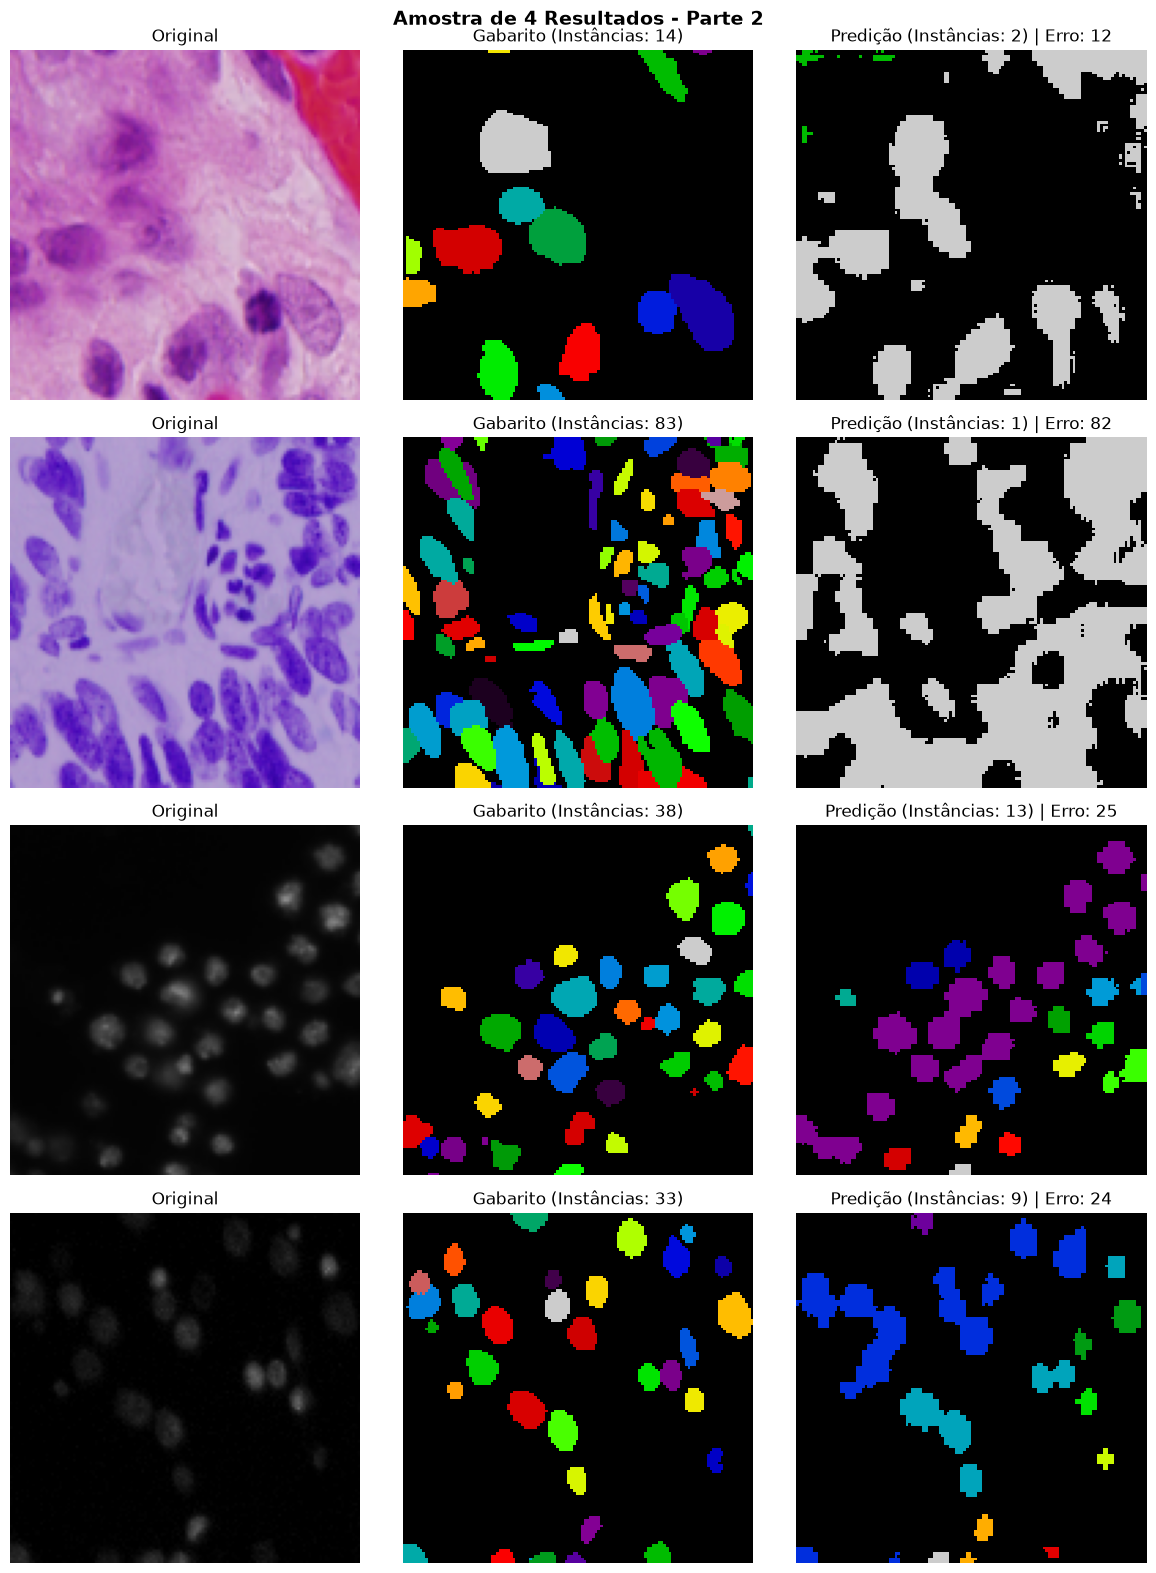

In [7]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate(real_model, real_val_loader, device, part =2)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=2)

## Part 3

Eixos escolhidos 1 e 3

In [ ]:
mean_map_1, std_map_1 = ablation(real_train_loader, real_val_loader, device, axis=1)


Avaliando Arquitetura: SegNet com seed 42
Epoch 1/10 | Loss: 9.2092 | IoU: 0.0621 | Dice: 0.1169
Epoch 2/10 | Loss: 5.7816 | IoU: 0.0272 | Dice: 0.0530
Epoch 3/10 | Loss: 5.2660 | IoU: 0.0894 | Dice: 0.1642
Epoch 4/10 | Loss: 4.9908 | IoU: 0.2027 | Dice: 0.3370
Epoch 5/10 | Loss: 4.8618 | IoU: 0.3041 | Dice: 0.4664
Epoch 6/10 | Loss: 4.7381 | IoU: 0.4039 | Dice: 0.5754
Epoch 7/10 | Loss: 4.6176 | IoU: 0.4700 | Dice: 0.6395
Epoch 8/10 | Loss: 4.5217 | IoU: 0.5486 | Dice: 0.7085
Epoch 9/10 | Loss: 4.4512 | IoU: 0.5905 | Dice: 0.7425
Epoch 10/10 | Loss: 4.3845 | IoU: 0.6190 | Dice: 0.7647
Avaliando Arquitetura: SegNet com seed 100
Epoch 1/10 | Loss: 10.4060 | IoU: 0.0751 | Dice: 0.1397
Epoch 2/10 | Loss: 5.8203 | IoU: 0.0003 | Dice: 0.0007
Epoch 3/10 | Loss: 5.3625 | IoU: 0.0013 | Dice: 0.0026
Epoch 4/10 | Loss: 5.2260 | IoU: 0.0118 | Dice: 0.0234
Epoch 5/10 | Loss: 4.9600 | IoU: 0.0929 | Dice: 0.1701
Epoch 6/10 | Loss: 4.8819 | IoU: 0.2194 | Dice: 0.3598
Epoch 7/10 | Loss: 4.6974 | IoU: 

UnboundLocalError: cannot access local variable 'architectures' where it is not associated with a value

In [2]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Real Train: 536, Real Val: 134, Real Test: 65


In [5]:
dicionario2 = ablation(real_train_loader, real_val_loader, device, axis=3)

Avaliando Arquitetura: ParseNet com seed 42
Epoch 1/10 | Loss: 11.3277 | IoU: 0.0779 | Dice: 0.1445
Epoch 2/10 | Loss: 4.7362 | IoU: 0.0000 | Dice: 0.0001
Epoch 3/10 | Loss: 4.4845 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 4.3363 | IoU: 0.0000 | Dice: 0.0000
Epoch 5/10 | Loss: 4.2210 | IoU: 0.0000 | Dice: 0.0001
Epoch 6/10 | Loss: 4.1413 | IoU: 0.0206 | Dice: 0.0404
Epoch 7/10 | Loss: 3.9173 | IoU: 0.1665 | Dice: 0.2855
Epoch 8/10 | Loss: 3.8210 | IoU: 0.4708 | Dice: 0.6402
Epoch 9/10 | Loss: 3.6704 | IoU: 0.5917 | Dice: 0.7435
Epoch 10/10 | Loss: 3.5987 | IoU: 0.6417 | Dice: 0.7818
Avaliando Arquitetura: ParseNet com seed 100
Epoch 1/10 | Loss: 10.4729 | IoU: 0.0026 | Dice: 0.0051
Epoch 2/10 | Loss: 4.8590 | IoU: 0.0000 | Dice: 0.0001
Epoch 3/10 | Loss: 4.4443 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 4.3121 | IoU: 0.0002 | Dice: 0.0004
Epoch 5/10 | Loss: 4.1597 | IoU: 0.0021 | Dice: 0.0042
Epoch 6/10 | Loss: 4.0085 | IoU: 0.0585 | Dice: 0.1105
Epoch 7/10 | Loss: 3.9041 | 

In [3]:
dicionario1 = ablation(real_train_loader, real_val_loader, device, axis=1)

Avaliando Arquitetura: DeepLab com seed 42
Epoch 1/10 | Loss: 10.7070 | IoU: 0.0839 | Dice: 0.1548
Epoch 2/10 | Loss: 6.3414 | IoU: 0.0005 | Dice: 0.0009
Epoch 3/10 | Loss: 5.7288 | IoU: 0.0008 | Dice: 0.0016
Epoch 4/10 | Loss: 5.1281 | IoU: 0.0000 | Dice: 0.0000
Epoch 5/10 | Loss: 4.8842 | IoU: 0.0000 | Dice: 0.0000
Epoch 6/10 | Loss: 4.7593 | IoU: 0.0003 | Dice: 0.0007
Epoch 7/10 | Loss: 4.6338 | IoU: 0.0003 | Dice: 0.0006
Epoch 8/10 | Loss: 4.5072 | IoU: 0.0000 | Dice: 0.0001
Epoch 9/10 | Loss: 4.4237 | IoU: 0.0000 | Dice: 0.0000
Epoch 10/10 | Loss: 4.3731 | IoU: 0.0000 | Dice: 0.0000
Avaliando Arquitetura: DeepLab com seed 100
Epoch 1/10 | Loss: 9.5078 | IoU: 0.0287 | Dice: 0.0557
Epoch 2/10 | Loss: 6.4248 | IoU: 0.0000 | Dice: 0.0000
Epoch 3/10 | Loss: 6.2629 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 6.1065 | IoU: 0.0000 | Dice: 0.0000
Epoch 5/10 | Loss: 5.8590 | IoU: 0.0000 | Dice: 0.0001
Epoch 6/10 | Loss: 5.5277 | IoU: 0.0000 | Dice: 0.0000
Epoch 7/10 | Loss: 5.2187 | IoU

Parte 4

In [ ]:
mosaic_img, mosaic_inst = create_mosaic_real(real_val, indices=[0, 1, 2, 3])

print(f"📦 Formato da imagem do mosaico: {mosaic_img.shape}")
print(f"🏷️ Formato da máscara de instâncias do mosaico: {mosaic_inst.shape}")
print(f"🔢 Total de instâncias únicas no mosaico: {len(np.unique(mosaic_inst)) - 1}")



In [ ]:

tiles, coords = mosaic_tile_inference_demo(mosaic_img, tile_size=128, overlap=32)

print(f"🧩 Número total de tiles gerados: {len(tiles)}")
print(f"📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: {coords[0]}")
print(f"📦 Formato de cada tile: {tiles[0].shape}")

In [ ]:
synthetic_model = UNetBinary()

real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start = time.time()
train_model(real_model, real_train_loader, device, part=1, num_epochs=5)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")
real_mAP, real_count_errors, real_densities, synthetic_samples = evaluate(real_model, real_val_loader, device, part =1)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(synthetic_samples, part=1)




real_model.to(device)
# 1. Inferência Ingênua (Antes da correção)
pred_naive = mosaic_inference_naive(real_model, mosaic_img, tile_size=128, overlap=32, device=device)
map_naive, err_naive, _ = calculate_instance_metrics(mosaic_inst, pred_naive)


In [ ]:
# 2. Inferência com Fusão (Depois da correção)
pred_fusion = mosaic_inference_with_fusion(real_model, mosaic_img, tile_size=128, overlap=32, device=device)
map_fusion, err_fusion, _ = calculate_instance_metrics(mosaic_inst, pred_fusion)

print(f"❌ ANTES (Ingênuo): mAP = {map_naive:.4f} | Erro de Contagem = {err_naive}")
print(f"✅ DEPOIS (Fusão) : mAP = {map_fusion:.4f} | Erro de Contagem = {err_fusion}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(mosaic_inst, cmap='nipy_spectral')
axes[0].set_title("Ground Truth (Mosaico 256x256)")
axes[0].axis('off')

axes[1].imshow(pred_naive, cmap='nipy_spectral')
axes[1].set_title(f"Predição Ingênua\n(Note os cortes nas bordas)\nmAP: {map_naive:.4f}")
axes[1].axis('off')

axes[2].imshow(pred_fusion, cmap='nipy_spectral')
axes[2].set_title(f"Predição com Fusão por Intersecção\n(Bordas Corrigidas)\nmAP: {map_fusion:.4f}")
axes[2].axis('off')



# Definindo a região do zoom (exemplo de uma janela de 60x60 pixels)
zoom_x_min, zoom_x_max = 90, 150
zoom_y_min, zoom_y_max = 90, 150

for ax in axes:
    ax.set_xlim(zoom_x_min, zoom_x_max)
    ax.set_ylim(zoom_y_max, zoom_y_min) # Y é invertido no imshow (de cima para baixo)

plt.tight_layout()
plt.show()